crop_top: int = 250
    crop_bottom: int = 950
    crop_left: int = 330
    crop_right: int = 1600

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — SMART PANEL CROPPER (Jupyter Notebook)
# ══════════════════════════════════════════════════════════════════════════════

import cv2
import re

# ─── Crop ratio table ────────────────────────────────────────────────────────
CROP_RATIOS = {
    (1, 1): (0.30, 0.70, 0.35, 0.68),
    (1, 2): (0.18, 0.50, 0.23, 0.70),
    (1, 3): (0.18, 0.50, 0.15, 0.78),
    (1, 4): (0.18, 0.50, 0.03, 0.78),

    (2, 1): (0.18, 0.70, 0.30, 0.68),
    (2, 2): (0.18, 0.75, 0.15, 0.70),
    (2, 3): (0.18, 0.73, 0.15, 0.78),
    (2, 4): (0.18, 0.75, 0.03, 0.78),

    (3, 1): (0.18, 0.85, 0.30, 0.62),
    (3, 2): (0.18, 0.85, 0.15, 0.66),   # default
    (3, 3): (0.18, 0.85, 0.16, 0.78),
    (3, 4): (0.18, 0.90, 0.17, 0.95),

    (4, 1): (0.01, 0.98, 0.38, 0.64),
    (4, 2): (0.01, 0.98, 0.13, 0.80),
    (4, 3): (0.01, 0.98, 0.15, 0.78),
    (4, 4): (0.01, 0.98, 0.05, 0.78),
}

# ─── OCR Grid Reader ─────────────────────────────────────────────────────────
def parse_grid_from_image(img):
    try:
        import pytesseract

        h = img.shape[0]
        header = img[:int(h * 0.12), :]

        text = pytesseract.image_to_string(header)
        print(f"[OCR] {text.strip()}")

        row_match = re.search(
            r'rows?\s*[=:]\s*(\d+)',
            text,
            re.IGNORECASE
        )

        col_match = re.search(
            r'col(?:umns?)?\s*[=:]\s*(\d+)',
            text,
            re.IGNORECASE
        )

        if row_match and col_match:
            return int(row_match.group(1)), int(col_match.group(1))

    except ImportError:
        print("pytesseract not installed")

    return None, None

# ─── Main Crop Function ──────────────────────────────────────────────────────
def crop_panel(
    image_path,
    output_path,
    rows=None,
    cols=None
):
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(image_path)

    # OCR fallback
    if rows is None or cols is None:
        ocr_rows, ocr_cols = parse_grid_from_image(img)

        rows = rows or ocr_rows or 3
        cols = cols or ocr_cols or 2

    rows = max(1, min(4, int(rows)))
    cols = max(1, min(4, int(cols)))

    left_r, right_r, top_r, bottom_r = CROP_RATIOS[(rows, cols)]

    h, w = img.shape[:2]

    left   = int(w * left_r)
    right  = int(w * right_r)
    top    = int(h * top_r)
    bottom = int(h * bottom_r)

    cropped = img[top:bottom, left:right]

    cv2.imwrite(output_path, cropped)

    print(f"Grid: {rows}×{cols}")
    print(f"Saved: {output_path}")

    return cropped

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — RUN
# ══════════════════════════════════════════════════════════════════════════════

IMAGE_PATH  = "/home/harsh-raj-112/Desktop/Input/Test26/Output/1/1_undistorted.jpeg"
OUTPUT_PATH = "cropped_panel.png"

cropped = crop_panel(
    IMAGE_PATH,
    OUTPUT_PATH,
    rows=2,
    cols=3
)

# ══════════════════════════════════════════════════════════════════════════════
# CELL — SHOW RESULT
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Cropped Panel")
plt.show()

[ WARN:0@0.043] global loadsave.cpp:278 findDecoder imread_('/home/harsh-raj-112/Desktop/Input/Test26/Output/1/1_undistorted.jpeg'): can't open/read file: check file path/integrity


FileNotFoundError: /home/harsh-raj-112/Desktop/Input/Test26/Output/1/1_undistorted.jpeg

✓ Step 3 – Preprocessed
✓ Step 4 – Binary (Otsu)
✓ Step 5 – Morphological
✓ Step 6 – Connected components  (19 components)
  Row zones : [(136, 310), (325, 500), (514, 691)]
  Col zones : [(73, 430), (446, 808), (823, 1195)]
  Valleys   : top=0 bottom=0 left=0 right=0
✓ Step 7 – Cells extracted & stitched


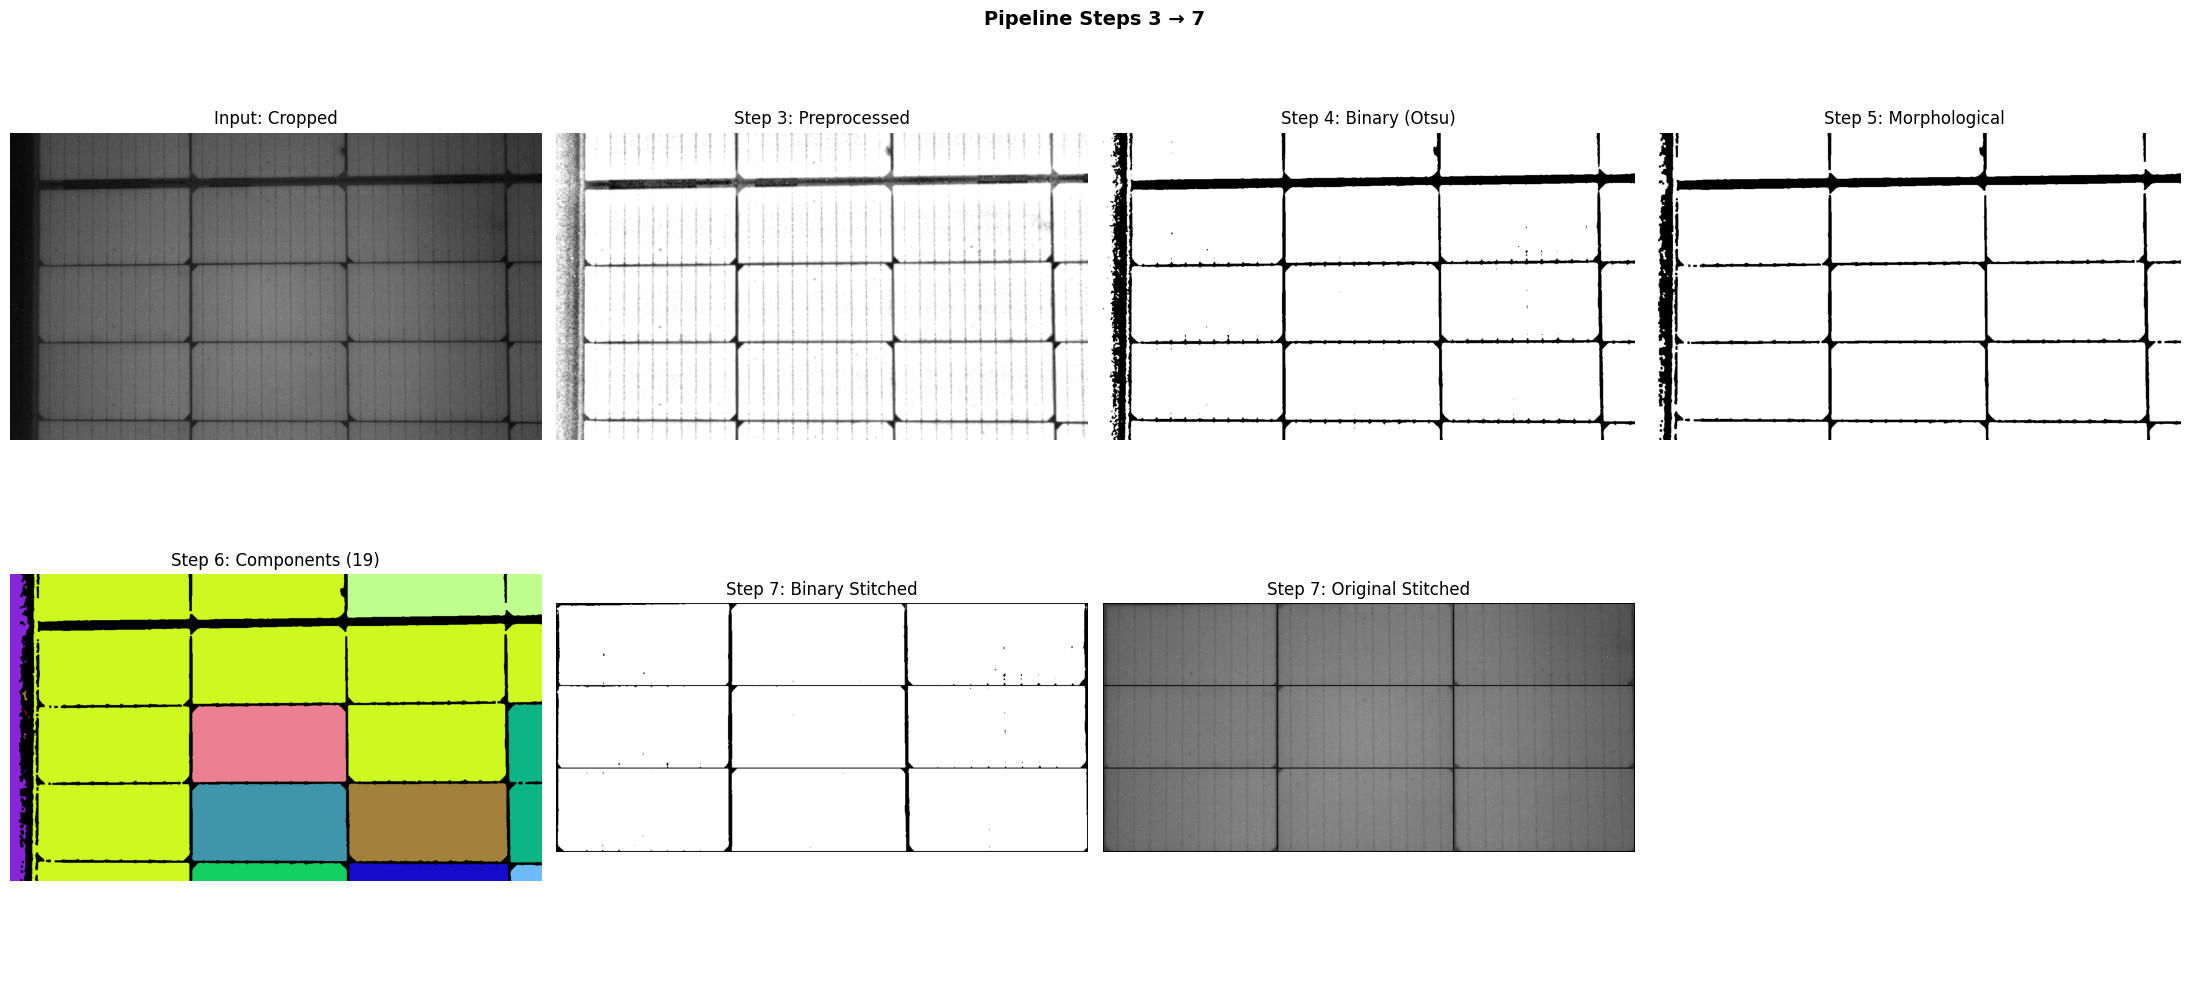

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ─────────────────────────────────────────────────────────────────
# CONFIG  (tweak as needed)
# ─────────────────────────────────────────────────────────────────
CROPPED_IMAGE_PATH = "cropped_panel.png"   # ← change to your cropped image path

ROWS = 3
COLS = 3
MARGIN = 2

VALLEY_MIN_PX          = 20
BORDER_TOP_EXTRA_PX    = 1
BORDER_BOTTOM_EXTRA_PX = 1
BORDER_LEFT_EXTRA_PX   = 1
BORDER_RIGHT_EXTRA_PX  = 1
CELL_H_PAD             = 7
CELL_V_PAD_TOP         = 12
CELL_V_PAD_BOTTOM      = 13

# ─────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────
def find_cell_boundaries(profile, n_cells, min_cell_size=30):
    DROP_RATIO = 0.20
    SMOOTH_WIN = 11
    LOCAL_WIN  = 80
    n = len(profile)
    kernel   = np.ones(SMOOTH_WIN) / SMOOTH_WIN
    smoothed = np.convolve(profile.astype(float), kernel, mode="same")
    local_peak = np.empty(n, dtype=float)
    for i in range(n):
        lo = max(0, i - LOCAL_WIN)
        hi = min(n, i + LOCAL_WIN + 1)
        local_peak[i] = smoothed[lo:hi].max()
    dark_mask = smoothed < local_peak * (1.0 - DROP_RATIO)
    zones, start = [], None
    for i, is_dark in enumerate(dark_mask):
        if not is_dark and start is None:
            start = i
        elif is_dark and start is not None:
            if i - start >= min_cell_size:
                zones.append((start, i))
            start = None
    if start is not None and n - start >= min_cell_size:
        zones.append((start, n))
    if len(zones) < n_cells:
        raise ValueError(f"Expected {n_cells} zones but found only {len(zones)}.")
    if len(zones) > n_cells:
        zones = sorted(zones, key=lambda z: z[1] - z[0], reverse=True)[:n_cells]
        zones = sorted(zones, key=lambda z: z[0])
    return zones

def measure_border_valley_width(profile, dark_threshold=30.0):
    left_width = sum(1 for v in profile if v < dark_threshold) if profile[0] < dark_threshold else 0
    left_width = 0
    for v in profile:
        if v < dark_threshold: left_width += 1
        else: break
    right_width = 0
    for v in reversed(profile):
        if v < dark_threshold: right_width += 1
        else: break
    return left_width, right_width

def stitch_grid(cells):
    col_widths  = [max(cells[r][c].width  for r in range(ROWS)) for c in range(COLS)]
    row_heights = [max(cells[r][c].height for c in range(COLS)) for r in range(ROWS)]
    out_w = sum(col_widths)  + MARGIN * (COLS + 1)
    out_h = sum(row_heights) + MARGIN * (ROWS + 1)
    canvas = Image.new("RGB", (out_w, out_h), (0, 0, 0))
    y = MARGIN
    for r in range(ROWS):
        x = MARGIN
        for c in range(COLS):
            canvas.paste(cells[r][c], (x, y))
            x += col_widths[c] + MARGIN
        y += row_heights[r] + MARGIN
    return canvas

# ─────────────────────────────────────────────────────────────────
# LOAD CROPPED IMAGE
# ─────────────────────────────────────────────────────────────────
cropped = cv2.imread(CROPPED_IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
assert cropped is not None, f"Could not read image: {CROPPED_IMAGE_PATH}"
colour_crop_bgr = cv2.imread(CROPPED_IMAGE_PATH)  # for original cells (RGB)
orig_pil = Image.fromarray(cv2.cvtColor(colour_crop_bgr, cv2.COLOR_BGR2RGB))
H, W = cropped.shape

# ─────────────────────────────────────────────────────────────────
# STEP 3 – Preprocess (denoise → illumination correction → CLAHE)
# ─────────────────────────────────────────────────────────────────
denoised   = cv2.GaussianBlur(cropped, (5, 5), 0)
background = cv2.GaussianBlur(denoised, (0, 0), 25)
normalized = cv2.divide(denoised, background, scale=255)
clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
step3_preprocessed = clahe.apply(normalized)
print("✓ Step 3 – Preprocessed")

# ─────────────────────────────────────────────────────────────────
# STEP 4 – Binarize (Gaussian blur + Otsu)
# ─────────────────────────────────────────────────────────────────
blur = cv2.GaussianBlur(step3_preprocessed, (5, 5), 0)
_, step4_binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("✓ Step 4 – Binary (Otsu)")

# ─────────────────────────────────────────────────────────────────
# STEP 5 – Morphological clean-up
# ─────────────────────────────────────────────────────────────────
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
step5_morph = cv2.morphologyEx(step4_binary, cv2.MORPH_CLOSE, kernel, iterations=2)
step5_morph = cv2.morphologyEx(step5_morph,  cv2.MORPH_OPEN,  kernel, iterations=1)
print("✓ Step 5 – Morphological")

# ─────────────────────────────────────────────────────────────────
# STEP 6 – Connected components (colour-coded)
# ─────────────────────────────────────────────────────────────────
num_labels, labels = cv2.connectedComponents(step5_morph)
rng = np.random.default_rng(42)
step6_comp = np.zeros((*labels.shape, 3), dtype=np.uint8)
for label in range(1, num_labels):
    step6_comp[labels == label] = rng.integers(0, 255, size=3, dtype=np.uint8)
n_components = num_labels - 1
print(f"✓ Step 6 – Connected components  ({n_components} components)")

# ─────────────────────────────────────────────────────────────────
# STEP 7 – Cell extraction + stitching
# ─────────────────────────────────────────────────────────────────
binary_arr = step4_binary   # cell extraction uses step-4 binary

x0 = int(W * 0.20); x1 = int(W * 0.80)
vertical_profile_mid   = binary_arr[:, x0:x1].astype(float).mean(axis=1)
row_zones = find_cell_boundaries(vertical_profile_mid, ROWS)

ry0, ry1  = row_zones[0][0], row_zones[-1][1]
ry_mid0   = ry0 + int((ry1 - ry0) * 0.20)
ry_mid1   = ry0 + int((ry1 - ry0) * 0.80)
horizontal_profile_mid = binary_arr[ry_mid0:ry_mid1, :].astype(float).mean(axis=0)
col_zones = find_cell_boundaries(horizontal_profile_mid, COLS)

top_valley_w,  bottom_valley_w = measure_border_valley_width(binary_arr[:, :].astype(float).mean(axis=1))
left_valley_w, right_valley_w  = measure_border_valley_width(binary_arr[ry0:ry1, :].astype(float).mean(axis=0))

add_top    = top_valley_w    >= VALLEY_MIN_PX
add_bottom = bottom_valley_w >= VALLEY_MIN_PX
add_left   = left_valley_w   >= VALLEY_MIN_PX
add_right  = right_valley_w  >= VALLEY_MIN_PX

print(f"  Row zones : {row_zones}")
print(f"  Col zones : {col_zones}")
print(f"  Valleys   : top={top_valley_w} bottom={bottom_valley_w} left={left_valley_w} right={right_valley_w}")

binary_pil = Image.fromarray(binary_arr)
binary_cells, orig_cells = [], []

for r, (ry_lo, ry_hi) in enumerate(row_zones):
    bin_row, orig_row = [], []
    for c, (cx_lo, cx_hi) in enumerate(col_zones):
        cell_ry_lo, cell_ry_hi = ry_lo, ry_hi
        cell_cx_lo, cell_cx_hi = cx_lo, cx_hi
        if add_top    and r == 0:        cell_ry_lo = max(0, ry_lo - BORDER_TOP_EXTRA_PX - CELL_V_PAD_TOP)
        if add_bottom and r == ROWS - 1: cell_ry_hi = min(H, ry_hi + BORDER_BOTTOM_EXTRA_PX + CELL_V_PAD_BOTTOM)
        if add_left   and c == 0:        cell_cx_lo = max(0, cx_lo - BORDER_LEFT_EXTRA_PX)
        if add_right  and c == COLS - 1: cell_cx_hi = min(W, cx_hi + BORDER_RIGHT_EXTRA_PX)
        cell_cx_lo = max(0, cell_cx_lo - CELL_H_PAD)
        cell_cx_hi = min(W, cell_cx_hi + CELL_H_PAD)
        box = (cell_cx_lo, cell_ry_lo, cell_cx_hi, cell_ry_hi)
        bin_row.append(binary_pil.crop(box))
        orig_row.append(orig_pil.crop(box))
    binary_cells.append(bin_row)
    orig_cells.append(orig_row)

step7_binary_stitched = stitch_grid(binary_cells)
step7_orig_stitched   = stitch_grid(orig_cells)
print("✓ Step 7 – Cells extracted & stitched")

# ─────────────────────────────────────────────────────────────────
# VISUALISE ALL STEPS
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

axes[0].imshow(cropped,            cmap="gray");                 axes[0].set_title("Input: Cropped")
axes[1].imshow(step3_preprocessed, cmap="gray");                 axes[1].set_title("Step 3: Preprocessed")
axes[2].imshow(step4_binary,       cmap="gray");                 axes[2].set_title("Step 4: Binary (Otsu)")
axes[3].imshow(step5_morph,        cmap="gray");                 axes[3].set_title("Step 5: Morphological")
axes[4].imshow(step6_comp);                                      axes[4].set_title(f"Step 6: Components ({n_components})")
axes[5].imshow(step7_binary_stitched);                           axes[5].set_title("Step 7: Binary Stitched")
axes[6].imshow(step7_orig_stitched);                             axes[6].set_title("Step 7: Original Stitched")
axes[7].axis("off")

for ax in axes[:7]: ax.axis("off")
plt.suptitle("Pipeline Steps 3 → 7", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Optional: save outputs
# cv2.imwrite("3_preprocessed.png",         step3_preprocessed)
# cv2.imwrite("4_binary.png",               step4_binary)
# cv2.imwrite("5_morphological.png",        step5_morph)
# cv2.imwrite("6_connected_components.png", step6_comp)
# step7_binary_stitched.save("7_binary_stitched.png")
# step7_orig_stitched.save("8_original_stitched.png")